# Case study: a toy database with a known answer

This notebook uses a synthetic database where **we defined the rule that generates the labels**, so the
correct explanation is known in advance and the method can be checked.

This is Example 1 of the paper, realised experimentally.

## The database

Three tables. `S` and `T` both reference `R` by a foreign key. Every attribute is standard
normal noise, **except** `S.X_Boolean`.

```
   R(rid, x1..x10)           1000 rows   -- the prediction entity
   S(sid, rid, x1..x5,       4000 rows   -- X_Boolean is the only informative attribute
       X_Boolean)
   T(tid, rid, x1..x5)       5000 rows   -- linked to R, but carries nothing
```

## Two tasks, two different right answers

| Task | Label rule | Correct `Projection` | Correct `FKJoin` |
|---|---|---|---|
| `count-1` | `#{s in S : s.rid = r.rid and s.X_Boolean} >= 2` | `S.X_Boolean` only | R–S only |
| `count-2` | `#{s in S : s.rid = r.rid} >= 4` | **nothing** | R–S only |

`count-2` is the interesting one. It counts linked rows *regardless of their values*, so no
attribute should matter. A column-level explanation method has no way to express that answer, which is the paper's argument for having more than one explanation language.

Neither task depends on `T`, so a correct `FKJoin` explanation drops the R–T join in both.

## Setup

Requires the `synthetic` bundle (~1.6 MB) unzipped under `artifacts/`. The bundles carry
the graph as well as the model, so nothing is rebuilt here.

To regenerate the underlying database from scratch:
`python scripts/generate_synthetic_rst.py --out-dir data/r-s-synthetic`.

In [8]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from rdl_explain.artifacts import load_bundle, load_explanation_task
from rdl_explain.explain.explainer import RDLExplainer
from rdl_explain.explain.masks import discretize_mask, explanation_size, DEFAULT_DELTA
from rdl_explain.explain.viz import plot_mask_importances, draw_schema_with_masks

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_INSTANCES = 200
N_EPOCHS = 150

# Regularization weight: how strongly the objective prefers a SMALL explanation.
EPS = 0.1

# (mask type, strategy used for mask learning, perturbation used for devDelta)
LANGUAGES = {
    "Projection": ("column", "permutation_joint", "permutation_joint"),
    "FKJoin":     ("fkpk",   "zero",              "foreign_key_uniform_random"),
}
print("device:", DEVICE)

device: cuda


In [9]:
def explain(bundle, seed=0):
    """Load a verified bundle and run both explanation languages on it."""
    torch.manual_seed(seed)
    model, data, col_stats, config, manifest = load_bundle(bundle, device=DEVICE)
    task = load_explanation_task(bundle, subsample_per_split=N_INSTANCES)
    explainer = RDLExplainer(config, model, data, task)

    results = {}
    for language, (mask_type, elimination, perturbation) in LANGUAGES.items():
        mask, _, _ = explainer.learn_masks(
            explanation_type=mask_type, elimination_strategy=elimination,
            eps=EPS, n_epochs=N_EPOCHS, lr=0.05,
        )
        hard = discretize_mask(mask)
        dev, sem, *_ = explainer.estimate_devdelta(
            mask=hard, explanation_type=mask_type,
            perturbation_strategy=perturbation, num_samples=5,
        )
        results[language] = {"mask": mask, "hard": hard, "dev": dev, "sem": sem,
                             "kept": [k for k, v in hard.items() if bool(v.any())]}
    return data, config, results


def show(results, title):
    """Per-language importance bars, from the package's shared helper."""
    for language, r in results.items():
        plot_mask_importances(
            r["mask"], delta=DEFAULT_DELTA,
            title=f"{title} — {language} (devDelta = {r['dev']:.4f})")
        plt.show()
        kept = sorted({f"{k[0]}.{k[1]}" if language == "Projection"
                       else f"{k[0]}-{k[2]}" for k in r["kept"]})
        print(f"{language:11s} k={explanation_size(r['hard']):2d}"
              f"/{len(r['hard']):<3d} keeps: {kept or 'NOTHING'}")


def schema(data, results, entity_table, num_layers, title):
    """Both explanations overlaid on the schema itself -- the paper's framing:
    an explanation is a VIEW over the database, not a ranking of graph parts."""
    return draw_schema_with_masks(
        data, entity_table=entity_table, view="flat",
        column_mask=results["Projection"]["mask"],
        fkpk_mask=results["FKJoin"]["mask"],
        num_layers=num_layers, delta=DEFAULT_DELTA, title=title)

## Task `count-1` — an attribute *and* a join

The label depends on `S.X_Boolean` and on the R–S join, so each language should recover
its own part of the rule.

In [ ]:
data_1, config_1, results_1 = explain("synthetic/count-1")

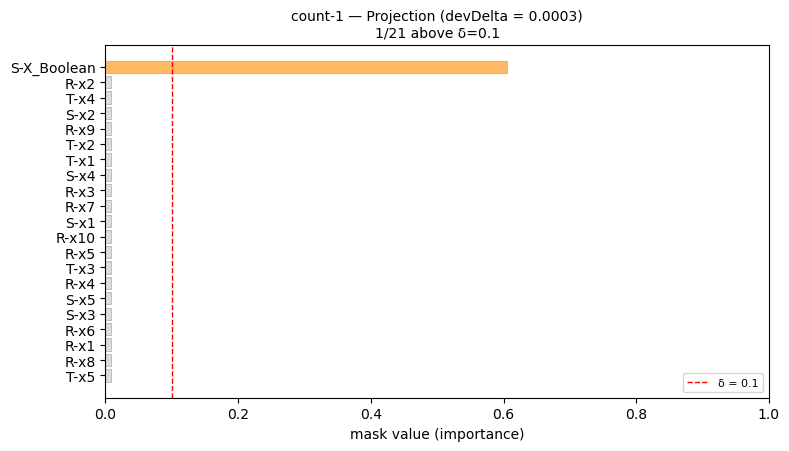

Projection  k= 1/21  keeps: ['S.X_Boolean']


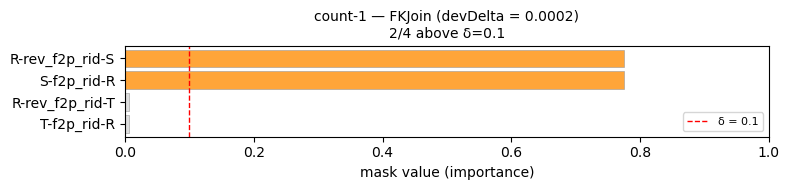

FKJoin      k= 2/4   keeps: ['R-S', 'S-R']


In [11]:
show(results_1, "count-1")

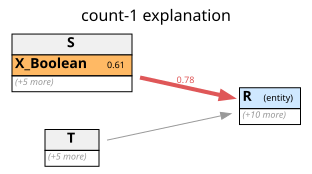

In [12]:
# Both explanations on the schema: shaded columns are the Projection view,
# weighted arrows the FKJoin view. This is the explanation as a database view.
schema(data_1, results_1, entity_table="R", num_layers=config_1.gnn_layers,
       title="count-1 explanation")

`Projection` picks out `S.X_Boolean` from 21 columns and discards the other 20 noise
attributes. `FKJoin` keeps R–S (both directions of the same relationship) and drops R–T.
Both devΔ values are ≈ 0, so what was kept is enough to determine the model's predictions.
This is the generating rule, recovered.

## Task `count-2` — structure without attributes

The label now counts linked `S` rows regardless of their values. No attribute should
matter, and the entire predictive signal should live in the join.

In [ ]:
data_2, config_2, results_2 = explain("synthetic/count-2")

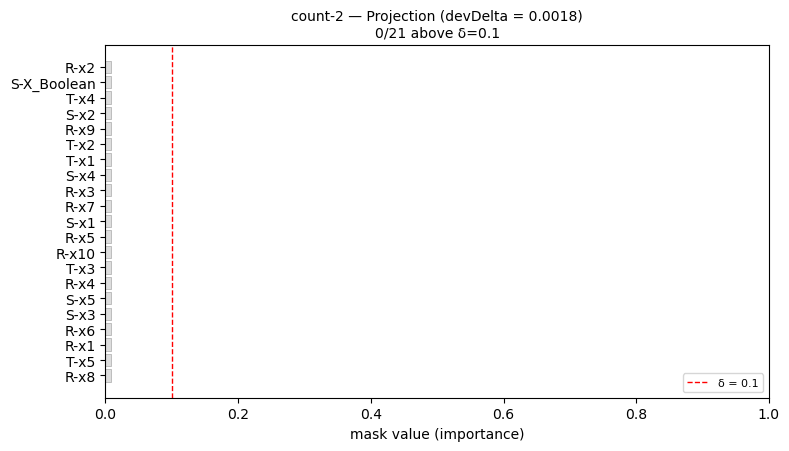

Projection  k= 0/21  keeps: NOTHING


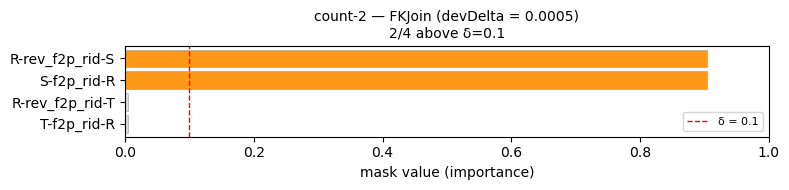

FKJoin      k= 2/4   keeps: ['R-S', 'S-R']


In [14]:
show(results_2, "count-2")

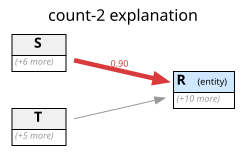

In [15]:
schema(data_2, results_2, entity_table="R", num_layers=config_2.gnn_layers,
       title="count-2 explanation")

`Projection` returns the **empty** explanation: not one of the 21 columns clears the
threshold, and devΔ stays ≈ 0 anyway, i.e., destroying every attribute barely moves the
model's predictions, because the model is not reading attributes at all.

That is the correct answer, and it is one a column-level explanation method cannot give. Asked
"which columns matter?", the truthful reply here is "none", but a method that only ranks
attributes would still hand you a ranked list, and its top entry would look meaningful.

`FKJoin` supplies what `Projection` cannot: R–S is retained with high importance, R–T is
dropped. The model is counting rows across a join. This is the pivot Example 1 describes.

## Summary

In [16]:
print(f"{'task':10s} {'language':11s} {'k':>4s} {'of':>4s} {'devDelta':>10s}   kept")
print("-" * 74)
for task, results in (("count-1", results_1), ("count-2", results_2)):
    for language, r in results.items():
        kept = sorted({f"{k[0]}.{k[1]}" if language == "Projection" else f"{k[0]}-{k[2]}"
                       for k in r["kept"]})
        print(f"{task:10s} {language:11s} {explanation_size(r['hard']):4d} "
              f"{len(r['hard']):4d} {r['dev']:10.4f}   {', '.join(kept) or '(empty)'}")

task       language       k   of   devDelta   kept
--------------------------------------------------------------------------
count-1    Projection     1   21     0.0003   S.X_Boolean
count-1    FKJoin         2    4     0.0002   R-S, S-R
count-2    Projection     0   21     0.0018   (empty)
count-2    FKJoin         2    4     0.0005   R-S, S-R


Both tasks recover their generating rule exactly, and `count-2` shows why the framework
spans several languages rather than one: the same database, the same model architecture,
and the answer moves from an attribute to a join.

### A note on `EPS`

`EPS` is the weight on explanation size in the objective. Set it too low and elements the
model does not need can still sit above the threshold. 

### Next

`03_case_study_clinical_trials.ipynb` runs all three languages, adding `Selection`, which
filters *rows* rather than columns on a real clinical-trials database, to diagnose data
leakage that was deliberately planted. The ground truth is known there too, but the
database is real and the schema is large.